# Inventory-aware quote skew

I use fixed seeds here so the numerical examples remain comparable when the implementation changes.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd() if (Path.cwd()/"src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT/"src"))
pd.set_option("display.max_columns", 30)

I check whether inventory skew actually changes the direction of expected fills: positive inventory should move the bid away and the ask closer, encouraging inventory reduction.

In [2]:
from market_maker_lab.quoting import construct_quote
rows=[]
for q in range(-20,21,2):
    quote=construct_quote(100,q,.05,.003,.005,.4,4,.001,40)
    rows.append({"inventory":q,"bid":quote.bid,"ask":quote.ask,"bid_distance":100-quote.bid,"ask_distance":quote.ask-100})
quotes=pd.DataFrame(rows); quotes.head()

,inventory,bid,ask,bid_distance,ask_distance
0,-20,99.995,100.095,0.005,0.095
1,-18,99.995,100.095,0.005,0.095
2,-16,99.995,100.095,0.005,0.095
3,-14,99.992,100.092,0.008,0.092
4,-12,99.986,100.086,0.014,0.086


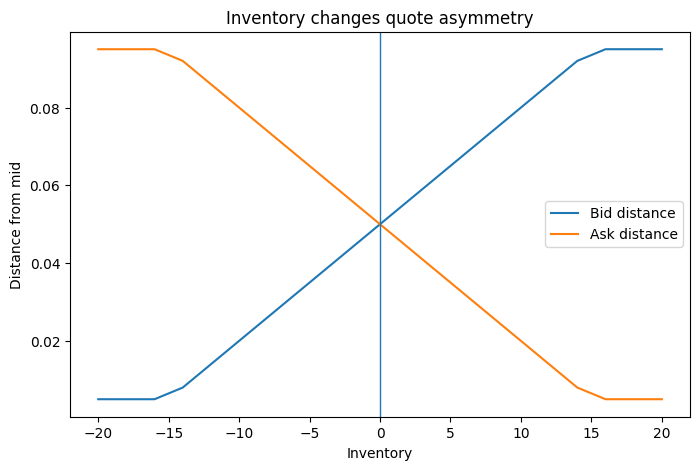

In [3]:
plt.figure(figsize=(8,5)); plt.plot(quotes.inventory,quotes.bid_distance,label="Bid distance"); plt.plot(quotes.inventory,quotes.ask_distance,label="Ask distance"); plt.axvline(0,linewidth=1); plt.xlabel("Inventory"); plt.ylabel("Distance from mid"); plt.legend(); plt.title("Inventory changes quote asymmetry"); plt.show()

In [4]:
robust=pd.read_csv(ROOT/"outputs/tables/robustness_inventory_skew.csv")
robust[["inventory_skew","mean_terminal_pnl","pnl_5_percentile","mean_absolute_inventory","mean_maximum_inventory"]]

,inventory_skew,mean_terminal_pnl,pnl_5_percentile,mean_absolute_inventory,mean_maximum_inventory
0,0.0000,-1.533851,-34.472025,22.264683,38.444444
1,0.0015,2.254157,-18.851814,13.337302,21.277778
2,0.0030,2.196889,-11.817812,8.669048,14.611111
3,0.0060,2.954210,-5.231495,5.539286,10.611111
